# Nigeria Food Procurement Intelligence Agent

## Notebook 01 — Data Validation and Exploratory Analysis

This notebook investigates the structure, quality, geographic coverage and time-series suitability of the public WFP Nigeria Food Prices dataset.

The analysis aims to identify market–commodity–unit–price-type combinations that are sufficiently reliable for honest forecasting experiments.

Public price observations are treated as decision-support evidence rather than guaranteed current or future prices.

**Security boundary:** This project uses only public WFP data and clearly labelled synthetic examples. It contains no employer, customer, client or confidential information.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display


# Find the repository root whether the notebook starts in the
# repository directory or inside the notebooks directory.
PROJECT_ROOT = next(
    (
        path
        for path in [Path.cwd(), *Path.cwd().parents]
        if (path / "src" / "validation.py").exists()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find the project root containing src/validation.py."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.validation import build_validation_report, load_dataset


DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "wfp_food_prices_nga.csv"
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {DATA_PATH}")

Project root: C:\Users\HP\Documents\GitHub\nigeria-food-procurement-agent
Dataset path: C:\Users\HP\Documents\GitHub\nigeria-food-procurement-agent\data\raw\wfp_food_prices_nga.csv


## 1. Data Loading and Validation

The raw CSV is loaded through the project's reusable validation module.

The source file is not edited. A separate in-memory analytical copy is created for date and numeric conversions. If a required conversion fails, the notebook should stop rather than silently discard the affected observation.

In [2]:
raw_df = load_dataset(DATA_PATH)
validation_report = build_validation_report(
    raw_df,
    DATA_PATH,
)

# Work on a separate in-memory copy.
analysis_df = raw_df.copy()

analysis_df["date"] = pd.to_datetime(
    analysis_df["date"],
    errors="raise",
)

numeric_columns = [
    "market_id",
    "commodity_id",
    "latitude",
    "longitude",
    "price",
    "usdprice",
]

for column in numeric_columns:
    analysis_df[column] = pd.to_numeric(
        analysis_df[column],
        errors="raise",
    )

print(f"Raw shape: {raw_df.shape}")
print(f"Analytical shape: {analysis_df.shape}")
print(
    "Basic validation passed:",
    validation_report["passes_basic_validation"],
)
print(
    "Date range:",
    analysis_df["date"].min().date(),
    "to",
    analysis_df["date"].max().date(),
)

Raw shape: (81534, 16)
Analytical shape: (81534, 16)
Basic validation passed: True
Date range: 2002-01-15 to 2026-07-15


## 2. Data Dictionary

| Variable | Meaning |
|---|---|
| `date` | Monthly observation timestamp |
| `admin1` | First-level administrative area or state |
| `admin2` | Second-level administrative area |
| `market` | Market name |
| `market_id` | Market identifier |
| `latitude` | Market latitude |
| `longitude` | Market longitude |
| `category` | Broad commodity category |
| `commodity` | Commodity name |
| `commodity_id` | Commodity identifier |
| `unit` | Quantity represented by the recorded price |
| `priceflag` | Actual, aggregate or combined observation flag |
| `pricetype` | Retail or wholesale classification |
| `currency` | Currency of the local price |
| `price` | Price expressed in local currency |
| `usdprice` | Converted US-dollar price |

In [3]:
display(analysis_df.head(5))

analysis_df.info()

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,2002-01-15,Katsina,Jibia,Jibia (CBM),1038,13.08,7.24,cereals and tubers,Maize,51,KG,actual,Wholesale,NGN,175.92,1.54
1,2002-01-15,Katsina,Jibia,Jibia (CBM),1038,13.08,7.24,cereals and tubers,Millet,73,KG,actual,Wholesale,NGN,150.18,1.31
2,2002-01-15,Katsina,Jibia,Jibia (CBM),1038,13.08,7.24,cereals and tubers,Rice (imported),64,KG,actual,Wholesale,NGN,358.70,3.14
3,2002-01-15,Katsina,Jibia,Jibia (CBM),1038,13.08,7.24,cereals and tubers,Sorghum,65,KG,actual,Wholesale,NGN,155.61,1.36
4,2002-01-15,Katsina,Jibia,Jibia (CBM),1038,13.08,7.24,pulses and nuts,Beans (niebe),120,KG,actual,Wholesale,NGN,196.87,1.72


<class 'pandas.DataFrame'>
RangeIndex: 81534 entries, 0 to 81533
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          81534 non-null  datetime64[us]
 1   admin1        81534 non-null  str           
 2   admin2        81534 non-null  str           
 3   market        81534 non-null  str           
 4   market_id     81534 non-null  int64         
 5   latitude      81534 non-null  float64       
 6   longitude     81534 non-null  float64       
 7   category      81534 non-null  str           
 8   commodity     81534 non-null  str           
 9   commodity_id  81534 non-null  int64         
 10  unit          81534 non-null  str           
 11  priceflag     81534 non-null  str           
 12  pricetype     81534 non-null  str           
 13  currency      81534 non-null  str           
 14  price         81534 non-null  float64       
 15  usdprice      81534 non-null  float64       
dt

In [4]:
quality = validation_report["quality"]

quality_summary = pd.DataFrame(
    {
        "check": [
            "Missing values",
            "Invalid dates",
            "Invalid prices",
            "Non-positive prices",
            "Exact duplicate rows",
            "Logical duplicate rows",
            "Globally invalid coordinates",
            "Coordinates outside broad Nigeria bounds",
            "Market IDs linked to multiple names",
            "Commodity IDs linked to multiple names",
        ],
        "result": [
            analysis_df.isna().sum().sum(),
            quality["invalid_dates"],
            quality["invalid_prices"],
            quality["non_positive_prices"],
            quality["exact_duplicate_rows"],
            quality["logical_duplicate_rows"],
            quality["globally_invalid_coordinates"],
            quality["coordinates_outside_broad_nigeria_bounds"],
            quality["market_ids_with_multiple_names"],
            quality["commodity_ids_with_multiple_names"],
        ],
    }
)

display(quality_summary)

,check,result
0,Missing values,0
1,Invalid dates,0
2,Invalid prices,0
3,Non-positive prices,0
4,Exact duplicate rows,0
5,Logical duplicate rows,0
6,Globally invalid coordinates,0
7,Coordinates outside broad Nigeria bounds,0
8,Market IDs linked to multiple names,0
9,Commodity IDs linked to multiple names,0


In [5]:
def frequency_table(column: str) -> pd.DataFrame:
    """Return counts and percentages for one categorical variable."""

    result = (
        analysis_df[column]
        .value_counts(dropna=False)
        .rename("observations")
        .to_frame()
    )

    result["percentage"] = (
        result["observations"]
        .div(len(analysis_df))
        .mul(100)
        .round(2)
    )

    return result


print("Price types")
display(frequency_table("pricetype"))

print("Price flags")
display(frequency_table("priceflag"))

print("Measurement units")
display(frequency_table("unit"))

Price types


,observations,percentage
pricetype,,
Retail,61868,75.88
Wholesale,19666,24.12


Price flags


,observations,percentage
priceflag,,
actual,47771,58.59
aggregate,32646,40.04
"actual,aggregate",1117,1.37


Measurement units


,observations,percentage
unit,,
100 KG,15007,18.41
KG,14184,17.40
2.5 KG,9044,11.09
L,7158,8.78
2.7 KG,4344,5.33
400 G,4316,5.29
2.1 KG,4020,4.93
0.5 KG,3884,4.76
2.6 KG,2594,3.18


## 3. Geographic Coverage

This section measures how strongly different states and markets are represented in the dataset.

A high observation count means that the dataset contains more records for that location. It does not prove that the location has greater food production, demand or economic importance.

In [6]:
state_coverage = (
    analysis_df
    .groupby("admin1", as_index=False)
    .agg(
        observations=("date", "size"),
        markets=("market_id", "nunique"),
        commodities=("commodity_id", "nunique"),
        first_observation=("date", "min"),
        last_observation=("date", "max"),
    )
    .sort_values("observations", ascending=False)
)

state_coverage["observation_share_pct"] = (
    state_coverage["observations"]
    .div(len(analysis_df))
    .mul(100)
    .round(2)
)

display(state_coverage)

,admin1,observations,markets,commodities,first_observation,last_observation,observation_share_pct
2,Borno,29024,28,41,2003-02-15,2026-07-15,35.60
12,Yobe,26810,18,38,2015-01-15,2026-06-15,32.88
5,Kaduna,3820,2,18,2013-11-15,2023-01-15,4.69
7,Katsina,2995,3,21,2002-01-15,2023-01-15,3.67
1,Adamawa,2448,7,37,2015-01-15,2025-11-15,3.00
6,Kano,2311,1,18,2003-08-15,2023-01-15,2.83
4,Jigawa,2228,2,19,2009-01-15,2023-01-15,2.73
10,Oyo,2146,1,19,2010-09-15,2023-01-15,2.63
8,Kebbi,2093,1,17,2014-07-15,2023-01-15,2.57
13,Zamfara,2079,1,18,2013-11-15,2023-01-15,2.55


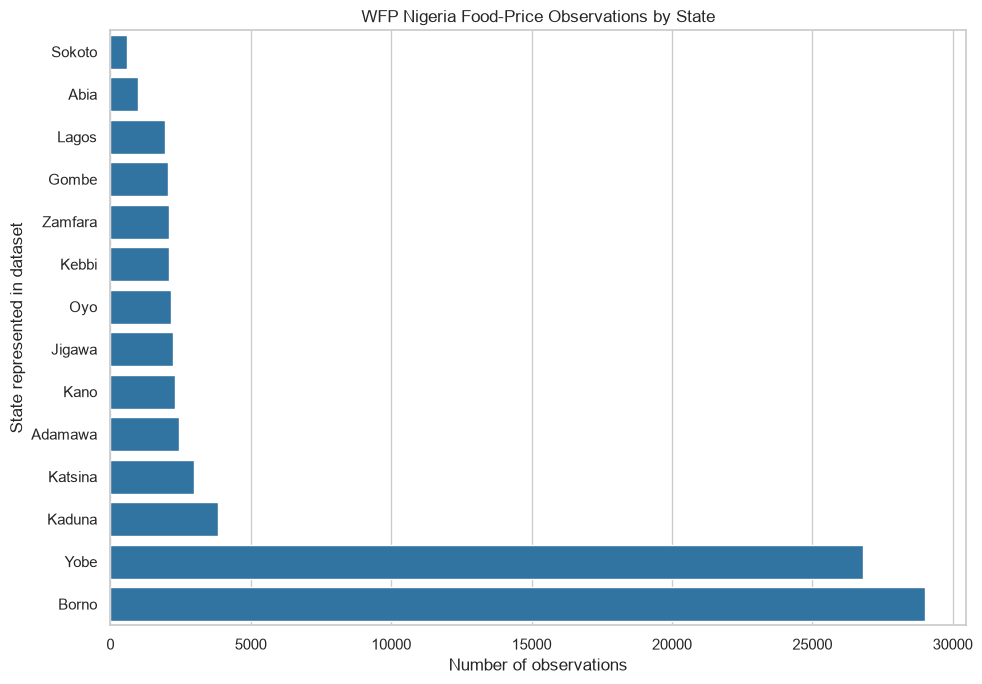

Chart saved to: C:\Users\HP\Documents\GitHub\nigeria-food-procurement-agent\assets\state_observation_coverage.png


In [7]:
FIGURE_DIRECTORY = PROJECT_ROOT / "assets"
FIGURE_DIRECTORY.mkdir(exist_ok=True)

state_plot_data = state_coverage.sort_values(
    "observations",
    ascending=True,
)

plt.figure(figsize=(10, 7))

axis = sns.barplot(
    data=state_plot_data,
    x="observations",
    y="admin1",
    color="#1f77b4",
)

axis.set_title("WFP Nigeria Food-Price Observations by State")
axis.set_xlabel("Number of observations")
axis.set_ylabel("State represented in dataset")

plt.tight_layout()

state_chart_path = (
    FIGURE_DIRECTORY
    / "state_observation_coverage.png"
)

plt.savefig(
    state_chart_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(f"Chart saved to: {state_chart_path}")

In [8]:
market_coverage = (
    analysis_df
    .groupby(
        [
            "market_id",
            "market",
            "admin1",
            "admin2",
        ],
        as_index=False,
    )
    .agg(
        observations=("date", "size"),
        commodities=("commodity_id", "nunique"),
        units=("unit", "nunique"),
        first_observation=("date", "min"),
        last_observation=("date", "max"),
    )
    .sort_values("observations", ascending=False)
)

display(market_coverage.head(15))

,market_id,market,admin1,admin2,observations,commodities,units,first_observation,last_observation
19,1981,Potiskum,Yobe,Potiskum,3664,38,19,2015-01-15,2026-05-15
14,1976,Dawanau,Kano,Dawakin Tofa,2311,18,10,2003-08-15,2023-01-15
31,2394,Abba Gamaram,Borno,Konduga,2300,27,15,2016-01-15,2026-06-15
21,2384,Budum,Borno,Maiduguri,2261,27,15,2016-06-15,2026-04-15
32,2395,Custom,Borno,Maiduguri,2260,27,15,2016-06-15,2026-06-15
25,2388,Bade (Gashua),Yobe,Karasuwa,2241,27,15,2016-12-15,2026-06-15
30,2393,Geidam,Yobe,Geidam,2231,27,15,2016-12-15,2026-03-15
17,1979,Maiduguri,Borno,Maiduguri,2214,38,19,2012-05-15,2024-12-15
34,2397,Monday,Borno,Maiduguri,2212,27,15,2016-06-15,2026-06-15
27,2390,Gujba (Buni Yadi),Yobe,Gujba,2210,27,15,2016-12-15,2026-06-15


## 4. Commodity Coverage

The number of observations available for each commodity determines how much historical evidence is available.

Observation volume alone is not enough for forecasting. A commodity can have many observations across different markets while each individual market-level series remains short or incomplete.

In [9]:
commodity_coverage = (
    analysis_df
    .groupby(
        [
            "commodity_id",
            "commodity",
            "category",
        ],
        as_index=False,
    )
    .agg(
        observations=("date", "size"),
        states=("admin1", "nunique"),
        markets=("market_id", "nunique"),
        units=("unit", "nunique"),
        price_types=("pricetype", "nunique"),
        first_observation=("date", "min"),
        last_observation=("date", "max"),
    )
    .sort_values("observations", ascending=False)
)

commodity_coverage["observation_share_pct"] = (
    commodity_coverage["observations"]
    .div(len(analysis_df))
    .mul(100)
    .round(2)
)

display(commodity_coverage.head(20))

,commodity_id,commodity,category,observations,states,markets,units,price_types,first_observation,last_observation,observation_share_pct
8,73,Millet,cereals and tubers,4753,14,68,3,2,2002-01-15,2026-07-15,5.83
3,64,Rice (imported),cereals and tubers,4130,14,66,3,2,2002-01-15,2026-07-15,5.07
15,99,Yam,cereals and tubers,3886,13,64,3,2,2014-07-15,2026-07-15,4.77
7,71,Rice (local),cereals and tubers,3760,13,64,2,2,2014-07-15,2026-07-15,4.61
2,62,Oil (palm),oil and fats,2919,13,64,3,2,2014-05-15,2026-07-15,3.58
19,135,Sorghum (white),cereals and tubers,2361,13,16,2,2,2003-08-15,2023-01-15,2.90
6,67,Maize (white),cereals and tubers,2321,13,16,2,2,2003-08-15,2023-01-15,2.85
4,65,Sorghum,cereals and tubers,2163,6,54,2,2,2002-01-15,2026-07-15,2.65
10,78,Beans (red),pulses and nuts,2137,3,51,1,1,2016-01-15,2026-07-15,2.62
27,238,Milk (powder),milk and dairy,2110,3,51,1,1,2016-01-15,2026-07-15,2.59


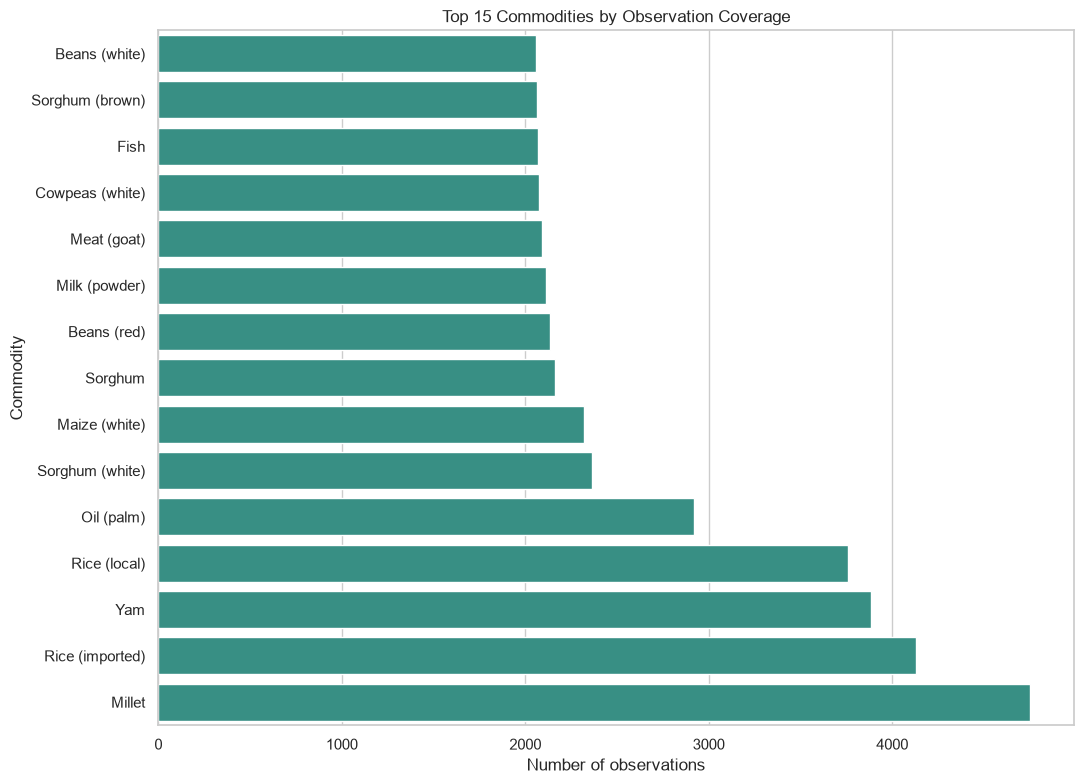

Chart saved to: C:\Users\HP\Documents\GitHub\nigeria-food-procurement-agent\assets\top_commodity_coverage.png


In [10]:
top_commodities = (
    commodity_coverage
    .head(15)
    .sort_values("observations", ascending=True)
)

plt.figure(figsize=(11, 8))

axis = sns.barplot(
    data=top_commodities,
    x="observations",
    y="commodity",
    color="#2a9d8f",
)

axis.set_title("Top 15 Commodities by Observation Coverage")
axis.set_xlabel("Number of observations")
axis.set_ylabel("Commodity")

plt.tight_layout()

commodity_chart_path = (
    FIGURE_DIRECTORY
    / "top_commodity_coverage.png"
)

plt.savefig(
    commodity_chart_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(f"Chart saved to: {commodity_chart_path}")

In [11]:
commodity_unit_summary = (
    analysis_df
    .groupby(
        ["commodity_id", "commodity"],
        as_index=False,
    )
    .agg(
        unit_count=("unit", "nunique"),
        units=(
            "unit",
            lambda values: ", ".join(
                sorted(values.unique())
            ),
        ),
    )
    .sort_values(
        ["unit_count", "commodity"],
        ascending=[False, True],
    )
)

multi_unit_commodities = commodity_unit_summary[
    commodity_unit_summary["unit_count"] > 1
]

display(multi_unit_commodities)

,commodity_id,commodity,unit_count,units
20,136,Maize (yellow),3,"100 KG, 50 KG, KG"
8,73,Millet,3,"100 KG, 2.6 KG, KG"
2,62,Oil (palm),3,"100 KG, 100 L, L"
3,64,Rice (imported),3,"2.8 KG, 50 KG, KG"
15,99,Yam,3,"100 KG, 100 Tubers, 2.5 KG"
39,484,Yam (Abuja),3,"100 KG, 100 Tubers, KG"
37,482,"Cassava meal (gari, yellow)",2,"100 KG, KG"
35,480,Cowpeas (brown),2,"100 KG, KG"
34,479,Cowpeas (white),2,"100 KG, KG"
38,483,Gari (white),2,"100 KG, KG"


In [12]:
highest_state = state_coverage.iloc[0]
lowest_state = state_coverage.iloc[-1]
highest_market = market_coverage.iloc[0]
highest_commodity = commodity_coverage.iloc[0]

print(
    "Highest state coverage:",
    highest_state["admin1"],
    f"({highest_state['observations']:,} observations)",
)

print(
    "Lowest state coverage:",
    lowest_state["admin1"],
    f"({lowest_state['observations']:,} observations)",
)

print(
    "Highest market coverage:",
    highest_market["market"],
    f"({highest_market['observations']:,} observations)",
)

print(
    "Highest commodity coverage:",
    highest_commodity["commodity"],
    f"({highest_commodity['observations']:,} observations)",
)

print(
    "Commodities represented by multiple units:",
    len(multi_unit_commodities),
)

Highest state coverage: Borno (29,024 observations)
Lowest state coverage: Sokoto (576 observations)
Highest market coverage: Potiskum (3,664 observations)
Highest commodity coverage: Millet (4,753 observations)
Commodities represented by multiple units: 17


## 5. Time-Series Continuity

Forecasting requires more than a large total number of observations. Each market–commodity series needs enough observations across time and must not contain excessive missing months.

A series is defined by market, commodity, measurement unit, price type and currency. These fields are kept separate to prevent incompatible prices from being combined.

In [13]:
analysis_df["month"] = (
    analysis_df["date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

SERIES_KEY = [
    "market_id",
    "commodity_id",
    "unit",
    "pricetype",
    "currency",
]

series_coverage = (
    analysis_df
    .groupby(SERIES_KEY, as_index=False)
    .agg(
        state=("admin1", "first"),
        market=("market", "first"),
        category=("category", "first"),
        commodity=("commodity", "first"),
        observations=("month", "size"),
        observed_months=("month", "nunique"),
        first_month=("month", "min"),
        last_month=("month", "max"),
        priceflag_types=("priceflag", "nunique"),
        actual_share=(
            "priceflag",
            lambda values: values.eq("actual").mean(),
        ),
    )
)

series_coverage["expected_months"] = (
    (
        series_coverage["last_month"].dt.year
        - series_coverage["first_month"].dt.year
    )
    * 12
    + (
        series_coverage["last_month"].dt.month
        - series_coverage["first_month"].dt.month
    )
    + 1
)

series_coverage["missing_months"] = (
    series_coverage["expected_months"]
    - series_coverage["observed_months"]
)

series_coverage["completeness_ratio"] = (
    series_coverage["observed_months"]
    / series_coverage["expected_months"]
)

series_coverage["duplicate_month_observations"] = (
    series_coverage["observations"]
    - series_coverage["observed_months"]
)

latest_dataset_month = analysis_df["month"].max()
recent_cutoff = latest_dataset_month - pd.DateOffset(months=12)

series_coverage["at_least_36_months"] = (
    series_coverage["observed_months"] >= 36
)

series_coverage["at_least_60_months"] = (
    series_coverage["observed_months"] >= 60
)

series_coverage["at_least_80_pct_complete"] = (
    series_coverage["completeness_ratio"] >= 0.80
)

series_coverage["recent_coverage"] = (
    series_coverage["last_month"] >= recent_cutoff
)

series_coverage["all_actual_observations"] = (
    series_coverage["actual_share"] == 1.0
)

series_coverage.shape

(1857, 24)

In [14]:
eligible_36_80 = (
    series_coverage["at_least_36_months"]
    & series_coverage["at_least_80_pct_complete"]
)

strong_candidate_mask = (
    series_coverage["at_least_60_months"]
    & series_coverage["at_least_80_pct_complete"]
    & series_coverage["recent_coverage"]
    & series_coverage["all_actual_observations"]
)

continuity_summary = pd.DataFrame(
    {
        "measure": [
            "Total series",
            "Series containing missing months",
            "Series with no internal missing months",
            "Series with at least 36 observed months",
            "Series with 36 months and 80% completeness",
            "Series with at least 60 observed months",
            "Series updated within the latest 12 months",
            "Series containing only actual observations",
            "Strong pilot candidates",
        ],
        "result": [
            len(series_coverage),
            series_coverage["missing_months"].gt(0).sum(),
            series_coverage["missing_months"].eq(0).sum(),
            series_coverage["at_least_36_months"].sum(),
            eligible_36_80.sum(),
            series_coverage["at_least_60_months"].sum(),
            series_coverage["recent_coverage"].sum(),
            series_coverage["all_actual_observations"].sum(),
            strong_candidate_mask.sum(),
        ],
    }
)

display(continuity_summary)

,measure,result
0,Total series,1857
1,Series containing missing months,1539
2,Series with no internal missing months,318
3,Series with at least 36 observed months,875
4,Series with 36 months and 80% completeness,430
5,Series with at least 60 observed months,623
6,Series updated within the latest 12 months,1035
7,Series containing only actual observations,146
8,Strong pilot candidates,0


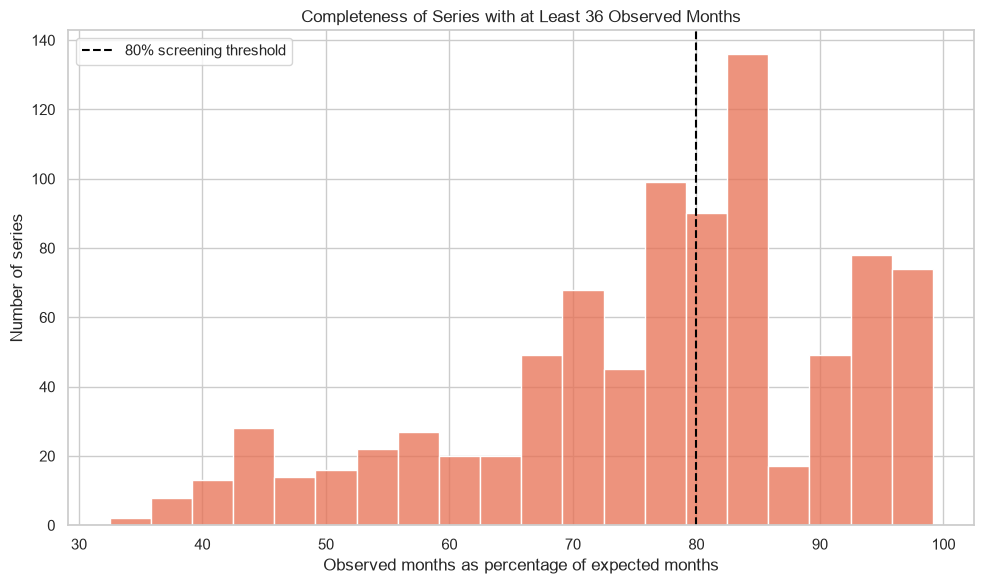

Chart saved to: C:\Users\HP\Documents\GitHub\nigeria-food-procurement-agent\assets\series_completeness_distribution.png


In [15]:
established_series = series_coverage[
    series_coverage["observed_months"] >= 36
].copy()

established_series["completeness_pct"] = (
    established_series["completeness_ratio"] * 100
)

plt.figure(figsize=(10, 6))

sns.histplot(
    data=established_series,
    x="completeness_pct",
    bins=20,
    color="#e76f51",
)

plt.axvline(
    80,
    color="black",
    linestyle="--",
    label="80% screening threshold",
)

plt.title(
    "Completeness of Series with at Least 36 Observed Months"
)
plt.xlabel("Observed months as percentage of expected months")
plt.ylabel("Number of series")
plt.legend()
plt.tight_layout()

completeness_chart_path = (
    FIGURE_DIRECTORY
    / "series_completeness_distribution.png"
)

plt.savefig(
    completeness_chart_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(f"Chart saved to: {completeness_chart_path}")

In [16]:
pilot_candidates = (
    series_coverage[strong_candidate_mask]
    .copy()
)

pilot_candidates["completeness_pct"] = (
    pilot_candidates["completeness_ratio"]
    * 100
)

pilot_candidates = pilot_candidates.sort_values(
    [
        "completeness_ratio",
        "observed_months",
        "last_month",
    ],
    ascending=[False, False, False],
)

candidate_columns = [
    "state",
    "market",
    "commodity",
    "unit",
    "pricetype",
    "observed_months",
    "expected_months",
    "missing_months",
    "completeness_pct",
    "first_month",
    "last_month",
]

display(pilot_candidates[candidate_columns].head(20))

,state,market,commodity,unit,pricetype,observed_months,expected_months,missing_months,completeness_pct,first_month,last_month


In [17]:
print(continuity_summary.to_string(index=False))

print("\nTOP 10 PILOT CANDIDATES")

print(
    pilot_candidates[candidate_columns]
    .head(10)
    .to_string(index=False)
)

                                   measure  result
                              Total series    1857
          Series containing missing months    1539
    Series with no internal missing months     318
   Series with at least 36 observed months     875
Series with 36 months and 80% completeness     430
   Series with at least 60 observed months     623
Series updated within the latest 12 months    1035
Series containing only actual observations     146
                   Strong pilot candidates       0

TOP 10 PILOT CANDIDATES
Empty DataFrame
Columns: [state, market, commodity, unit, pricetype, observed_months, expected_months, missing_months, completeness_pct, first_month, last_month]
Index: []


In [18]:
history_mask = (
    series_coverage["observed_months"] >= 60
)

history_completeness_mask = (
    history_mask
    & (
        series_coverage["completeness_ratio"]
        >= 0.80
    )
)

history_completeness_recent_mask = (
    history_completeness_mask
    & series_coverage["recent_coverage"]
)

consistent_flag_mask = (
    history_completeness_recent_mask
    & (
        series_coverage["priceflag_types"]
        == 1
    )
)

all_actual_mask = (
    history_completeness_recent_mask
    & series_coverage["all_actual_observations"]
)

filter_attrition = pd.DataFrame(
    {
        "screening_stage": [
            "All series",
            "At least 60 observed months",
            "Add at least 80% completeness",
            "Add coverage within latest 12 months",
            "Add one consistent price-flag type",
            "Require all observations to be actual",
        ],
        "remaining_series": [
            len(series_coverage),
            history_mask.sum(),
            history_completeness_mask.sum(),
            history_completeness_recent_mask.sum(),
            consistent_flag_mask.sum(),
            all_actual_mask.sum(),
        ],
    }
)

filter_attrition["removed_at_stage"] = (
    filter_attrition["remaining_series"]
    .shift(1)
    .sub(filter_attrition["remaining_series"])
)

display(filter_attrition)

,screening_stage,remaining_series,removed_at_stage
0,All series,1857,NaN
1,At least 60 observed months,623,"1,234.00"
2,Add at least 80% completeness,394,229.00
3,Add coverage within latest 12 months,185,209.00
4,Add one consistent price-flag type,0,185.00
5,Require all observations to be actual,0,0.00


In [19]:
eligible_before_flag_filter = series_coverage[
    history_completeness_recent_mask
].copy()

print("PRICE-FLAG TYPE COUNTS")

print(
    eligible_before_flag_filter["priceflag_types"]
    .value_counts()
    .sort_index()
    .to_string()
)

print("\nACTUAL-SHARE DISTRIBUTION")

print(
    eligible_before_flag_filter["actual_share"]
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
        ]
    )
    .to_string()
)

PRICE-FLAG TYPE COUNTS
priceflag_types
2     52
3    133

ACTUAL-SHARE DISTRIBUTION
count   185.00
mean      0.71
std       0.06
min       0.42
10%       0.64
25%       0.70
50%       0.71
75%       0.75
90%       0.76
max       0.80


In [20]:
relaxed_candidate_mask = (
    series_coverage["at_least_60_months"]
    & series_coverage["at_least_80_pct_complete"]
    & series_coverage["recent_coverage"]
)

relaxed_candidates = (
    series_coverage[relaxed_candidate_mask]
    .copy()
)

relaxed_candidates["completeness_pct"] = (
    relaxed_candidates["completeness_ratio"]
    * 100
)

relaxed_candidates["actual_share_pct"] = (
    relaxed_candidates["actual_share"]
    * 100
)

relaxed_candidates = relaxed_candidates.sort_values(
    [
        "completeness_ratio",
        "priceflag_types",
        "observed_months",
        "last_month",
    ],
    ascending=[
        False,
        True,
        False,
        False,
    ],
)

relaxed_columns = [
    "state",
    "market",
    "commodity",
    "unit",
    "pricetype",
    "observed_months",
    "expected_months",
    "missing_months",
    "completeness_pct",
    "priceflag_types",
    "actual_share_pct",
    "first_month",
    "last_month",
]

print(
    relaxed_candidates[relaxed_columns]
    .head(20)
    .to_string(index=False)
)

state            market       commodity   unit pricetype  observed_months  expected_months  missing_months  completeness_pct  priceflag_types  actual_share_pct first_month last_month
 Yobe          Potiskum Rice (imported) 2.8 KG    Retail              106              114               8             92.98                3             41.51  2016-12-01 2026-05-01
 Yobe          Potiskum    Rice (local) 2.7 KG    Retail              106              114               8             92.98                3             41.51  2016-12-01 2026-05-01
 Yobe          Potiskum          Millet 2.6 KG    Retail              106              114               8             92.98                3             41.51  2016-12-01 2026-05-01
 Yobe Gujba (Buni Yadi)         Sorghum 2.7 KG    Retail               93              106              13             87.74                3             63.44  2017-09-01 2026-06-01
 Yobe Gujba (Buni Yadi)           Sugar  500 G    Retail               93            

In [21]:
clear_units = [
    "KG",
    "50 KG",
    "100 KG",
    "L",
]

core_food_pattern = (
    r"Rice|Maize|Millet|Sorghum|Beans|"
    r"Oil|Onions|Yam|Meat"
)

business_candidates = relaxed_candidates[
    relaxed_candidates["unit"].isin(clear_units)
    & relaxed_candidates["commodity"].str.contains(
        core_food_pattern,
        case=False,
        regex=True,
        na=False,
    )
].copy()

selection_columns = [
    "market_id",
    "commodity_id",
    "state",
    "market",
    "commodity",
    "unit",
    "pricetype",
    "observed_months",
    "expected_months",
    "missing_months",
    "completeness_pct",
    "priceflag_types",
    "actual_share_pct",
    "first_month",
    "last_month",
]

print("FILTER ATTRITION")
print(filter_attrition.to_string(index=False))

print("\nTOP RETAIL CANDIDATES WITH CLEAR UNITS")

print(
    business_candidates[
        business_candidates["pricetype"] == "Retail"
    ][selection_columns]
    .head(10)
    .to_string(index=False)
)

print("\nTOP WHOLESALE CANDIDATES WITH CLEAR UNITS")

print(
    business_candidates[
        business_candidates["pricetype"] == "Wholesale"
    ][selection_columns]
    .head(10)
    .to_string(index=False)
)

FILTER ATTRITION
                      screening_stage  remaining_series  removed_at_stage
                           All series              1857               NaN
          At least 60 observed months               623          1,234.00
        Add at least 80% completeness               394            229.00
 Add coverage within latest 12 months               185            209.00
   Add one consistent price-flag type                 0            185.00
Require all observations to be actual                 0              0.00

TOP RETAIL CANDIDATES WITH CLEAR UNITS
 market_id  commodity_id state market       commodity unit pricetype  observed_months  expected_months  missing_months  completeness_pct  priceflag_types  actual_share_pct first_month last_month
      2384            62 Borno  Budum      Oil (palm)    L    Retail              101              119              18             84.87                3             76.24  2016-06-01 2026-04-01
      2384           141 Borno  Bud

## 6. Provisional Pilot Series

The first pilot series is retail palm-oil pricing in litres at Budum market, Borno State.

This series was selected because it combines business relevance, a clear measurement unit, recent observations and more than eight years of reasonably complete monthly history.

The selection remains provisional. Missing months, price-flag transitions and unusual price movements must be investigated before forecasting.

In [22]:
pilot_df = (
    analysis_df[
        analysis_df["market_id"].eq(2384)
        & analysis_df["commodity_id"].eq(62)
        & analysis_df["unit"].eq("L")
        & analysis_df["pricetype"].eq("Retail")
    ]
    .copy()
    .sort_values("month")
)

pilot_identity = pilot_df[
    [
        "admin1",
        "market",
        "market_id",
        "commodity",
        "commodity_id",
        "unit",
        "pricetype",
        "currency",
    ]
].drop_duplicates()

display(pilot_identity)

print("Pilot observations:", len(pilot_df))
print(
    "Duplicate pilot months:",
    pilot_df["month"].duplicated().sum(),
)

assert len(pilot_identity) == 1
assert len(pilot_df) == 101
assert pilot_df["month"].duplicated().sum() == 0

,admin1,market,market_id,commodity,commodity_id,unit,pricetype,currency
7787,Borno,Budum,2384,Oil (palm),62,L,Retail,NGN


Pilot observations: 101
Duplicate pilot months: 0


In [23]:
complete_month_index = pd.date_range(
    start=pilot_df["month"].min(),
    end=pilot_df["month"].max(),
    freq="MS",
)

pilot_monthly = (
    pilot_df
    .set_index("month")[
        [
            "price",
            "priceflag",
        ]
    ]
    .reindex(complete_month_index)
    .rename_axis("month")
    .reset_index()
)

pilot_monthly["is_missing"] = (
    pilot_monthly["price"].isna()
)

missing_pilot_months = (
    pilot_monthly.loc[
        pilot_monthly["is_missing"],
        "month",
    ]
    .dt.strftime("%Y-%m")
    .tolist()
)

print("Expected months:", len(pilot_monthly))
print("Observed months:", pilot_monthly["price"].notna().sum())
print("Missing months:", pilot_monthly["price"].isna().sum())
print("Missing month list:")
print(missing_pilot_months)

Expected months: 119
Observed months: 101
Missing months: 18
Missing month list:
['2022-06', '2022-07', '2022-08', '2022-09', '2022-10', '2022-11', '2022-12', '2023-01', '2023-12', '2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06', '2024-07', '2025-07', '2025-08']


In [24]:
observed_pilot = (
    pilot_monthly
    .dropna(subset=["price"])
    .copy()
)

observed_pilot["flag_changed"] = (
    observed_pilot["priceflag"]
    .ne(observed_pilot["priceflag"].shift())
)

flag_regimes = observed_pilot.loc[
    observed_pilot["flag_changed"],
    [
        "month",
        "priceflag",
    ],
]

pilot_flag_summary = (
    observed_pilot["priceflag"]
    .value_counts()
    .rename("observations")
    .to_frame()
)

pilot_flag_summary["percentage"] = (
    pilot_flag_summary["observations"]
    .div(len(observed_pilot))
    .mul(100)
    .round(2)
)

print("PILOT PRICE-FLAG DISTRIBUTION")
display(pilot_flag_summary)

print("DATES ON WHICH THE RECORDED FLAG CHANGED")
display(flag_regimes)

PILOT PRICE-FLAG DISTRIBUTION


,observations,percentage
priceflag,,
actual,77,76.24
aggregate,22,21.78
"actual,aggregate",2,1.98


DATES ON WHICH THE RECORDED FLAG CHANGED


,month,priceflag
0,2016-06-01,actual
84,2023-06-01,"actual,aggregate"
85,2023-07-01,aggregate
117,2026-03-01,"actual,aggregate"
118,2026-04-01,actual


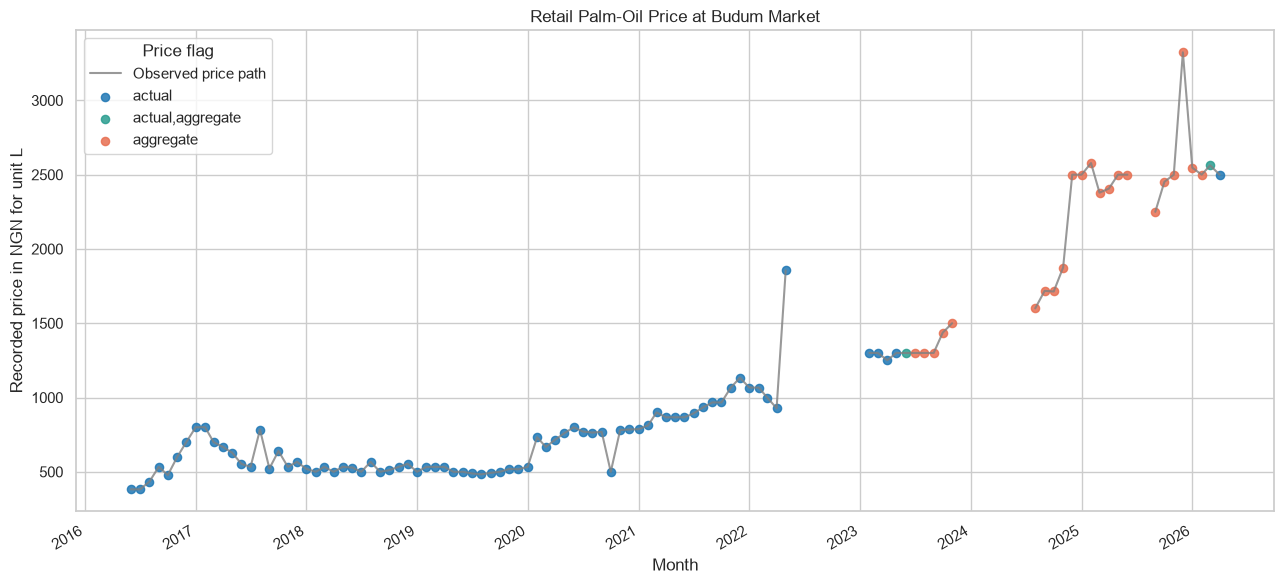

PNG saved to: C:\Users\HP\Documents\GitHub\nigeria-food-procurement-agent\assets\pilot_palm_oil_price_history.png
SVG saved to: C:\Users\HP\Documents\GitHub\nigeria-food-procurement-agent\assets\pilot_palm_oil_price_history.svg


In [25]:
flag_colours = {
    "actual": "#1f77b4",
    "aggregate": "#e76f51",
    "actual,aggregate": "#2a9d8f",
}

figure, axis = plt.subplots(figsize=(13, 6))

axis.plot(
    pilot_monthly["month"],
    pilot_monthly["price"],
    color="grey",
    linewidth=1.5,
    alpha=0.8,
    label="Observed price path",
)

for flag, group in pilot_df.groupby("priceflag"):
    axis.scatter(
        group["month"],
        group["price"],
        label=flag,
        color=flag_colours.get(flag, "black"),
        s=35,
        alpha=0.85,
    )

axis.set_title(
    "Retail Palm-Oil Price at Budum Market"
)
axis.set_xlabel("Month")
axis.set_ylabel("Recorded price in NGN for unit L")
axis.legend(title="Price flag")

figure.autofmt_xdate()
figure.tight_layout()

pilot_png_path = (
    FIGURE_DIRECTORY
    / "pilot_palm_oil_price_history.png"
)

pilot_svg_path = (
    FIGURE_DIRECTORY
    / "pilot_palm_oil_price_history.svg"
)

figure.savefig(
    pilot_png_path,
    dpi=200,
    bbox_inches="tight",
)

figure.savefig(
    pilot_svg_path,
    bbox_inches="tight",
)

plt.show()

print(f"PNG saved to: {pilot_png_path}")
print(f"SVG saved to: {pilot_svg_path}")

In [26]:
pilot_monthly["monthly_change_pct"] = (
    pilot_monthly["price"]
    .pct_change(fill_method=None)
    .mul(100)
)

pilot_monthly["absolute_change_pct"] = (
    pilot_monthly["monthly_change_pct"].abs()
)

largest_movements = (
    pilot_monthly
    .dropna(subset=["monthly_change_pct"])
    .nlargest(10, "absolute_change_pct")
    [
        [
            "month",
            "price",
            "priceflag",
            "monthly_change_pct",
        ]
    ]
)

print("PRICE SUMMARY")
display(pilot_df["price"].describe().to_frame())

print("TEN LARGEST CONSECUTIVE-MONTH PRICE MOVEMENTS")
display(largest_movements)

PRICE SUMMARY


,price
count,101.00
mean,"1,063.04"
std,707.32
min,382.00
25%,533.00
50%,784.00
75%,"1,300.00"
max,"3,323.53"


TEN LARGEST CONSECUTIVE-MONTH PRICE MOVEMENTS


,month,price,priceflag,monthly_change_pct
71,2022-05-01,"1,856.00",actual,100.00
53,2020-11-01,781.00,actual,56.20
14,2017-08-01,784.00,actual,47.09
44,2020-02-01,733.00,actual,37.52
52,2020-10-01,500.00,actual,-34.98
15,2017-09-01,522.00,actual,-33.42
102,2024-12-01,"2,500.00",aggregate,33.33
114,2025-12-01,"3,323.53",aggregate,32.94
5,2016-11-01,600.00,actual,25.52
115,2026-01-01,"2,547.04",aggregate,-23.36


In [27]:
pilot_monthly["previous_month_price"] = (
    pilot_monthly["price"].shift(1)
)

pilot_monthly["next_month_price"] = (
    pilot_monthly["price"].shift(-1)
)

pilot_monthly["next_month_change_pct"] = (
    pilot_monthly["next_month_price"]
    .div(pilot_monthly["price"])
    .sub(1)
    .mul(100)
)

movement_context = pilot_monthly.loc[
    largest_movements.index,
    [
        "month",
        "previous_month_price",
        "price",
        "next_month_price",
        "priceflag",
        "monthly_change_pct",
        "next_month_change_pct",
    ],
].copy()

transition_months = set(flag_regimes["month"])

movement_context["flag_transition_month"] = (
    movement_context["month"].isin(transition_months)
)

movement_context = movement_context.sort_values(
    "monthly_change_pct",
    key=lambda values: values.abs(),
    ascending=False,
)

print("MISSING PILOT MONTHS")
print(", ".join(missing_pilot_months))

print("\nPRICE-FLAG REGIME STARTS")
print(flag_regimes.to_string(index=False))

print("\nLARGEST MOVEMENTS WITH SURROUNDING CONTEXT")
print(movement_context.to_string(index=False))

MISSING PILOT MONTHS
2022-06, 2022-07, 2022-08, 2022-09, 2022-10, 2022-11, 2022-12, 2023-01, 2023-12, 2024-01, 2024-02, 2024-03, 2024-04, 2024-05, 2024-06, 2024-07, 2025-07, 2025-08

PRICE-FLAG REGIME STARTS
     month        priceflag
2016-06-01           actual
2023-06-01 actual,aggregate
2023-07-01        aggregate
2026-03-01 actual,aggregate
2026-04-01           actual

LARGEST MOVEMENTS WITH SURROUNDING CONTEXT
     month  previous_month_price    price  next_month_price priceflag  monthly_change_pct  next_month_change_pct  flag_transition_month
2022-05-01                928.00 1,856.00               NaN    actual              100.00                    NaN                  False
2020-11-01                500.00   781.00            785.00    actual               56.20                   0.51                  False
2017-08-01                533.00   784.00            522.00    actual               47.09                 -33.42                  False
2020-02-01                533.00   7

In [28]:
flag_period_summary = (
    pilot_df
    .groupby("priceflag", as_index=False)
    .agg(
        observations=("price", "size"),
        first_month=("month", "min"),
        last_month=("month", "max"),
        mean_price=("price", "mean"),
        median_price=("price", "median"),
        minimum_price=("price", "min"),
        maximum_price=("price", "max"),
    )
)

display(flag_period_summary)

,priceflag,observations,first_month,last_month,mean_price,median_price,minimum_price,maximum_price
0,actual,77,2016-06-01,2026-04-01,737.99,640.00,382.00,"2,500.00"
1,"actual,aggregate",2,2023-06-01,2026-03-01,"1,931.25","1,931.25","1,300.00","2,562.50"
2,aggregate,22,2023-07-01,2026-02-01,"2,121.80","2,392.64","1,300.00","3,323.53"


## Cross-Commodity Investigation of the May 2022 Price Movement

The selected palm-oil series recorded a 100% increase in May 2022, immediately before an extended reporting gap. This section compares other retail commodities in the same market to determine whether the movement was commodity-specific or market-wide.

In [29]:
from pathlib import Path
import pandas as pd

# Try the path used when Jupyter starts from the repository root.
data_path = Path("data/raw/wfp_food_prices_nga.csv")

# Use this alternative if Jupyter starts inside the notebooks folder.
if not data_path.exists():
    data_path = Path("../data/raw/wfp_food_prices_nga.csv")

if not data_path.exists():
    raise FileNotFoundError(
        "The WFP CSV was not found. Check the notebook's working directory."
    )

df = pd.read_csv(data_path, low_memory=False)

print("Dataset successfully loaded.")
print("Dataset path:", data_path.resolve())
print("Rows:", len(df))
print("Columns:", len(df.columns))

Dataset successfully loaded.
Dataset path: C:\Users\HP\Documents\GitHub\nigeria-food-procurement-agent\data\raw\wfp_food_prices_nga.csv
Rows: 81534
Columns: 16


In [30]:
import pandas as pd

cross_commodity_df = df.copy()

cross_commodity_df["month"] = (
    pd.to_datetime(cross_commodity_df["date"])
    .dt.to_period("M")
    .dt.to_timestamp()
)

april_2022 = pd.Timestamp("2022-04-01")
may_2022 = pd.Timestamp("2022-05-01")

budum_two_months = cross_commodity_df[
    (cross_commodity_df["market_id"] == 2384)
    & (cross_commodity_df["pricetype"] == "Retail")
    & (cross_commodity_df["month"].isin([april_2022, may_2022]))
].copy()

commodity_comparison = budum_two_months.pivot_table(
    index=["commodity_id", "commodity", "unit"],
    columns="month",
    values="price",
    aggfunc="first"
).dropna()

commodity_comparison["change_pct"] = (
    commodity_comparison[may_2022]
    .div(commodity_comparison[april_2022])
    .sub(1)
    .mul(100)
)

commodity_comparison = commodity_comparison.reset_index()

print("BUDUM APRIL–MAY 2022 INVESTIGATION")
print("Comparable commodities:", len(commodity_comparison))
print(
    "Median change:",
    round(commodity_comparison["change_pct"].median(), 2),
    "%"
)
print(
    "Commodities increasing by at least 90%:",
    commodity_comparison["change_pct"].ge(90).sum()
)

display(
    commodity_comparison[
        ["commodity", "unit", april_2022, may_2022, "change_pct"]
    ]
    .sort_values("change_pct", ascending=False)
    .head(20)
    .style.format({
        april_2022: "{:,.2f}",
        may_2022: "{:,.2f}",
        "change_pct": "{:,.2f}%"
    })
)

BUDUM APRIL–MAY 2022 INVESTIGATION
Comparable commodities: 24
Median change: 99.86 %
Commodities increasing by at least 90%: 14


month,commodity,unit,2022-04-01 00:00:00,2022-05-01 00:00:00,change_pct
16,Salt,250 G,88.00,200.00,127.27%
19,Bananas,1.3 KG,138.00,300.00,117.39%
22,Meat (goat),KG,"1,150.00","2,500.00",117.39%
8,Eggs,30 pcs,900.00,"1,900.00",111.11%
12,Fish,KG,225.00,467.00,107.56%
13,Meat (beef),KG,"1,188.00","2,450.00",106.23%
18,Milk (powder),400 G,"15,760.00","32,000.00",103.05%
0,Oil (palm),L,928.00,"1,856.00",100.00%
21,Spinach,300 G,25.00,50.00,100.00%
20,Oranges,400 G,50.00,100.00,100.00%


## Market-Level Missingness Investigation

The selected palm-oil series contains 18 missing months. This analysis checks whether other Budum retail commodities are missing during the same periods. Shared gaps would indicate a market-level data-collection interruption rather than a palm-oil-specific problem.

In [31]:
gap_df = df.copy()

gap_df["month"] = (
    pd.to_datetime(gap_df["date"])
    .dt.to_period("M")
    .dt.to_timestamp()
)

# Identify the selected palm-oil series.
pilot_gap_series = gap_df[
    (gap_df["market_id"] == 2384)
    & (gap_df["commodity_id"] == 62)
    & (gap_df["unit"] == "L")
    & (gap_df["pricetype"] == "Retail")
].sort_values("month")

pilot_start = pilot_gap_series["month"].min()
pilot_end = pilot_gap_series["month"].max()

pilot_expected_months = pd.date_range(
    pilot_start,
    pilot_end,
    freq="MS"
)

pilot_observed_months = set(pilot_gap_series["month"])

pilot_missing_months = {
    month for month in pilot_expected_months
    if month not in pilot_observed_months
}

# Select every retail commodity from Budum.
budum_retail = gap_df[
    (gap_df["market_id"] == 2384)
    & (gap_df["pricetype"] == "Retail")
].copy()

gap_results = []

for (commodity_id, commodity, unit), series in budum_retail.groupby(
    ["commodity_id", "commodity", "unit"]
):
    first_month = series["month"].min()
    last_month = series["month"].max()

    # Compare only series covering the pilot's full period.
    covers_pilot_period = (
        first_month <= pilot_start
        and last_month >= pilot_end
    )

    if not covers_pilot_period:
        continue

    expected_months = pd.date_range(
        first_month,
        last_month,
        freq="MS"
    )

    observed_months = set(series["month"])

    missing_months = {
        month for month in expected_months
        if month not in observed_months
    }

    shared_gaps = pilot_missing_months.intersection(missing_months)

    gap_results.append({
        "commodity": commodity,
        "unit": unit,
        "total_missing_months": len(missing_months),
        "shared_pilot_gaps": len(shared_gaps),
        "shares_all_18_pilot_gaps": (
            pilot_missing_months.issubset(missing_months)
        ),
        "exact_same_missing_pattern": (
            pilot_missing_months == missing_months
        )
    })

gap_report = pd.DataFrame(gap_results)

print("BUDUM MARKET-LEVEL MISSINGNESS TEST")
print("Pilot missing months:", len(pilot_missing_months))
print("Comparable full-period series:", len(gap_report))
print(
    "Series sharing all pilot gaps:",
    gap_report["shares_all_18_pilot_gaps"].sum()
)
print(
    "Series with exactly the same missing pattern:",
    gap_report["exact_same_missing_pattern"].sum()
)

display(
    gap_report.sort_values(
        ["shared_pilot_gaps", "total_missing_months"],
        ascending=[False, True]
    ).head(20)
)

BUDUM MARKET-LEVEL MISSINGNESS TEST
Pilot missing months: 18
Comparable full-period series: 13
Series sharing all pilot gaps: 13
Series with exactly the same missing pattern: 9


,commodity,unit,total_missing_months,shared_pilot_gaps,shares_all_18_pilot_gaps,exact_same_missing_pattern
0,Oil (palm),L,18,18,True,True
2,Rice (local),2.7 KG,18,18,True,True
4,Maize flour,2.1 KG,18,18,True,True
5,Beans (red),2.5 KG,18,18,True,True
6,Yam,2.5 KG,18,18,True,True
8,Meat (beef),KG,18,18,True,True
9,Groundnuts,2.2 KG,18,18,True,True
10,Onions,0.5 KG,18,18,True,True
12,Meat (goat),KG,18,18,True,True
1,Beans (white),2.5 KG,19,18,True,False


## Same-Commodity Market Comparison

The Budum missing periods affect multiple commodities and its May 2022 movement appears structural. This section compares retail palm-oil series from other markets using the same litre measurement unit. The objective is to select a defensible primary forecasting series and a secondary stress-test series.

In [32]:
comparison_df = df.copy()

comparison_df["month"] = (
    pd.to_datetime(comparison_df["date"])
    .dt.to_period("M")
    .dt.to_timestamp()
)

# Keep the same commodity, unit and price type.
palm_oil_markets = comparison_df[
    (comparison_df["commodity_id"] == 62)
    & (comparison_df["unit"] == "L")
    & (comparison_df["pricetype"] == "Retail")
].copy()

latest_dataset_month = comparison_df["month"].max()
recent_cutoff = latest_dataset_month - pd.DateOffset(months=12)

market_results = []

for (state, market, market_id), series in palm_oil_markets.groupby(
    ["admin1", "market", "market_id"]
):
    series = series.sort_values("month")

    first_month = series["month"].min()
    last_month = series["month"].max()

    expected_months = pd.date_range(
        first_month,
        last_month,
        freq="MS"
    )

    monthly_prices = (
        series.set_index("month")["price"]
        .reindex(expected_months)
    )

    # fill_method=None prevents Pandas from filling gaps automatically.
    monthly_changes = (
        monthly_prices.pct_change(fill_method=None) * 100
    )

    observed_months = series["month"].nunique()
    expected_month_count = len(expected_months)
    missing_months = expected_month_count - observed_months

    market_results.append({
        "state": state,
        "market": market,
        "market_id": market_id,
        "observed_months": observed_months,
        "expected_months": expected_month_count,
        "missing_months": missing_months,
        "completeness_pct": (
            observed_months / expected_month_count * 100
        ),
        "priceflag_types": series["priceflag"].nunique(),
        "actual_share_pct": (
            series["priceflag"].eq("actual").mean() * 100
        ),
        "median_abs_change_pct": monthly_changes.abs().median(),
        "maximum_abs_change_pct": monthly_changes.abs().max(),
        "first_month": first_month,
        "last_month": last_month,
        "recent_series": last_month >= recent_cutoff
    })

palm_market_summary = pd.DataFrame(market_results)

eligible_palm_markets = palm_market_summary[
    (palm_market_summary["observed_months"] >= 60)
    & (palm_market_summary["completeness_pct"] >= 80)
    & (palm_market_summary["recent_series"])
].sort_values(
    [
        "completeness_pct",
        "priceflag_types",
        "maximum_abs_change_pct"
    ],
    ascending=[False, True, True]
)

print("SAME-COMMODITY MARKET SCREEN")
print("All retail palm-oil markets:", len(palm_market_summary))
print("Eligible comparison markets:", len(eligible_palm_markets))
print("Latest dataset month:", latest_dataset_month.date())

display(
    eligible_palm_markets.head(15).style.format({
        "completeness_pct": "{:.2f}%",
        "actual_share_pct": "{:.2f}%",
        "median_abs_change_pct": "{:.2f}%",
        "maximum_abs_change_pct": "{:.2f}%"
    })
)

SAME-COMMODITY MARKET SCREEN
All retail palm-oil markets: 64
Eligible comparison markets: 7
Latest dataset month: 2026-07-01


,state,market,market_id,observed_months,expected_months,missing_months,completeness_pct,priceflag_types,actual_share_pct,median_abs_change_pct,maximum_abs_change_pct,first_month,last_month,recent_series
14,Borno,Budum,2384,101,119,18,84.87%,3,76.24%,4.38%,100.00%,2016-06-01 00:00:00,2026-04-01 00:00:00,True
52,Yobe,Geidam,2393,95,112,17,84.82%,2,70.53%,6.30%,50.00%,2016-12-01 00:00:00,2026-03-01 00:00:00,True
9,Borno,Baga Road,2385,98,118,20,83.05%,3,77.55%,6.19%,99.85%,2016-06-01 00:00:00,2026-03-01 00:00:00,True
62,Yobe,Yusufari,2389,93,112,19,83.04%,2,69.89%,6.67%,74.91%,2016-12-01 00:00:00,2026-03-01 00:00:00,True
45,Yobe,Bade (Gashua),2388,95,115,20,82.61%,3,71.58%,3.81%,66.75%,2016-12-01 00:00:00,2026-06-01 00:00:00,True
53,Yobe,Gujba (Buni Yadi),2390,94,115,21,81.74%,3,63.83%,5.22%,60.00%,2016-12-01 00:00:00,2026-06-01 00:00:00,True
8,Borno,Abba Gamaram,2394,102,126,24,80.95%,3,75.49%,3.35%,99.85%,2016-01-01 00:00:00,2026-06-01 00:00:00,True


## Final Pilot-Series Decision

Geidam retail palm oil measured per litre was selected as the primary forecasting pilot. It provides 95 observed months, 84.82% completeness, two price-flag types and a maximum observed consecutive-month movement of 50%.

Budum retail palm oil will be retained as a stress-test series. Although it has slightly higher completeness, it contains an approximately 100% May 2022 movement affecting several commodities and shares 18 missing months with other Budum series.

Using both markets reduces the risk of choosing a conveniently smooth series and allows the forecasting baselines to be evaluated under different data-quality conditions.

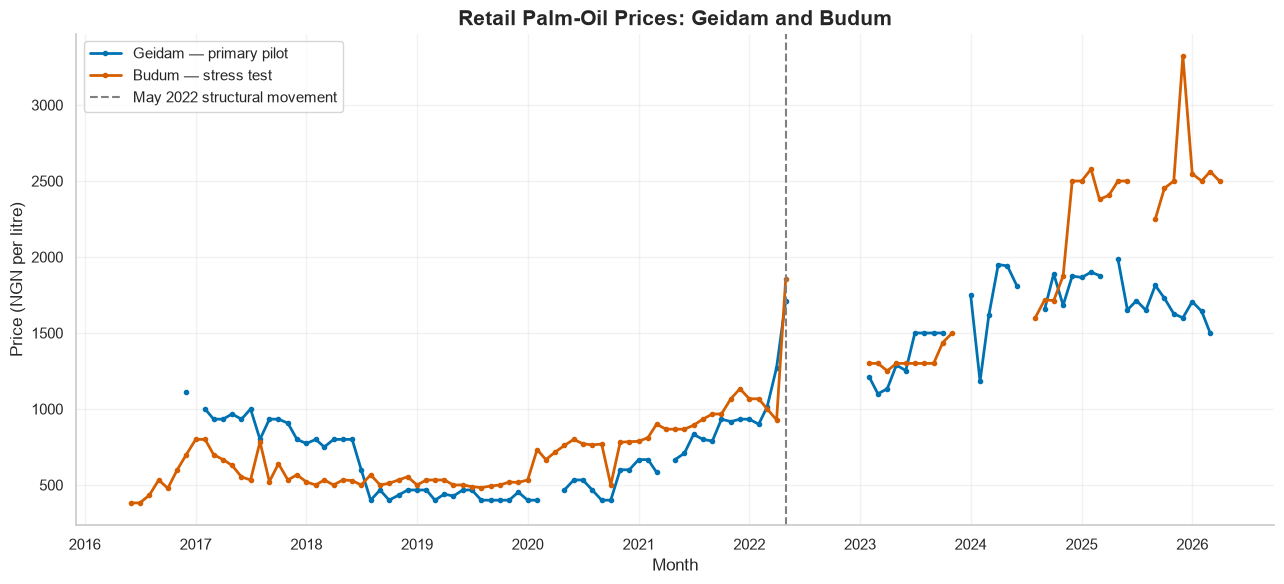

PNG saved to: C:\Users\HP\Documents\GitHub\nigeria-food-procurement-agent\assets\palm_oil_market_comparison.png
SVG saved to: C:\Users\HP\Documents\GitHub\nigeria-food-procurement-agent\assets\palm_oil_market_comparison.svg


In [33]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

chart_df = df.copy()

chart_df["month"] = (
    pd.to_datetime(chart_df["date"])
    .dt.to_period("M")
    .dt.to_timestamp()
)

selected_markets = {
    2393: "Geidam — primary pilot",
    2384: "Budum — stress test"
}

comparison_series = chart_df[
    (chart_df["market_id"].isin(selected_markets))
    & (chart_df["commodity_id"] == 62)
    & (chart_df["unit"] == "L")
    & (chart_df["pricetype"] == "Retail")
].copy()

fig, ax = plt.subplots(figsize=(13, 6))

colours = {
    2393: "#0072B2",
    2384: "#D55E00"
}

for market_id, label in selected_markets.items():
    market_data = comparison_series[
        comparison_series["market_id"] == market_id
    ].sort_values("month")

    complete_calendar = pd.date_range(
        market_data["month"].min(),
        market_data["month"].max(),
        freq="MS"
    )

    monthly_price = (
        market_data.set_index("month")["price"]
        .reindex(complete_calendar)
    )

    ax.plot(
        monthly_price.index,
        monthly_price.values,
        label=label,
        color=colours[market_id],
        linewidth=2,
        marker="o",
        markersize=3
    )

ax.axvline(
    pd.Timestamp("2022-05-01"),
    color="grey",
    linestyle="--",
    linewidth=1.5,
    label="May 2022 structural movement"
)

ax.set_title(
    "Retail Palm-Oil Prices: Geidam and Budum",
    fontsize=15,
    fontweight="bold"
)
ax.set_xlabel("Month")
ax.set_ylabel("Price (NGN per litre)")
ax.grid(alpha=0.25)
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Derive the repository root from the verified dataset location.
project_root = data_path.resolve().parents[2]

assets_directory = project_root / "assets"
assets_directory.mkdir(parents=True, exist_ok=True)

png_path = assets_directory / "palm_oil_market_comparison.png"
svg_path = assets_directory / "palm_oil_market_comparison.svg"

fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(svg_path, bbox_inches="tight")

plt.show()

print("PNG saved to:", png_path)
print("SVG saved to:", svg_path)

## Exploratory Analysis Conclusions

### Dataset quality

The public WFP Nigeria food-price dataset contains 81,534 observations and 16 variables, covering January 2002 to July 2026. It includes 14 states, 68 markets and 43 commodities.

The initial validation found no missing cells, invalid dates, non-positive prices, impossible coordinates or duplicated observation keys. However, the absence of empty cells does not mean that every time series is complete. Many market–commodity series contain missing calendar months.

### Coverage

The dataset contains 1,857 distinct market–commodity–unit–price-type series.

- 875 series have at least 36 observed months.
- 430 series have at least 36 observations and 80% completeness.
- 623 series have at least 60 observations.
- Only 318 series contain no internal missing months.
- No sufficiently long and recent candidate uses one price-flag type throughout its entire history.

Therefore, price-flag consistency was treated as a diagnostic characteristic rather than an absolute exclusion condition.

### Structural findings

The selected Budum palm-oil series contains 18 missing months. All 13 comparable Budum retail series covering the same full period share those 18 gaps, while nine have exactly the same missing pattern.

This is consistent with market-level data-collection interruptions rather than missingness specific to palm oil. The precise cause cannot be established from the dataset alone.

Palm oil increased by 100% in May 2022. A cross-commodity investigation found that 14 of 24 comparable Budum commodities increased by at least 90%, while the median increase was 99.86%.

This provides evidence of a broad structural movement affecting several commodities. It should not automatically be interpreted as either a genuine economic shock or a data error without additional evidence.

### Pilot selection

Geidam retail palm oil measured per litre was selected as the primary forecasting pilot.

It provides:

- 95 observed months;
- 84.82% completeness;
- two price-flag types;
- a maximum consecutive-month price movement of 50%;
- recent observations extending to March 2026.

Budum retail palm oil was retained as a stress-test series. It provides slightly higher completeness but contains a 100% structural movement and systematic market-level reporting gaps.

Evaluating forecasting baselines on both markets will reduce the risk of choosing only a conveniently smooth series.

### Modelling decisions

The forecasting stage will:

1. preserve the original observed prices;
2. retain price flags as data-quality information;
3. avoid filling long gaps using future information;
4. use chronological rather than random train/test splitting;
5. calculate changes only between genuinely consecutive calendar months;
6. evaluate models only where the required historical inputs and target observation exist;
7. report forecast coverage alongside forecast error;
8. perform sensitivity analysis around the May 2022 Budum structural movement;
9. treat forecasts as uncertain decision-support estimates rather than guaranteed future prices.

### Important limitations

The dataset does not provide supplier quotations, transportation costs, product quality, storage costs, quantity discounts or business-specific procurement requirements.

Consequently, the dataset can support market-price analysis and forecasting, but it cannot independently determine the final supplier or purchasing decision.